# Optimized PyTorch CNN with Optuna

In this notebook, we optimize a convolutional neural network (CNN) for the CIFAR-10 dataset using Optuna for hyperparameter tuning.

## Notebook set-up

### Imports

In [1]:
# Standard library imports
import pickle

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import optuna
import torch
import torch.optim as optim
from torchvision import datasets, transforms

# Package imports
import image_classification_tools.pytorch.data as data_utils
import image_classification_tools.pytorch.evaluation as eval_utils
import image_classification_tools.pytorch.hyperparameter_optimization as optimization
import image_classification_tools.pytorch.plotting as plots
import image_classification_tools.pytorch.training as training

# Local imports
import configuration as config

### Fixed hyperparameters

In [2]:
# Optuna settings
run_optimization = False # Run optimization (True) or load results for evaluation (False)
start_new_study = False  # Clear results/restart (True) or resume previous run (False) 
validation_size = 10000
n_trials = 200           # Number of optimization trials
n_epochs_per_trial = 200 # Epochs per trial
n_epochs_final = 200     # Epochs for final model training with optimized hyperparameters
print_every = 10         # Print training progress every n epochs

## 1. Visualize CIFAR-10 sample images

CIFAR-10 contains 32x32 color images (3 channels) across 10 classes.

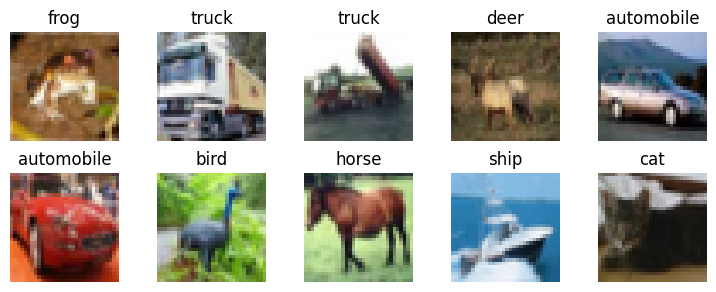

In [3]:
# Define transform (RGB)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Get a sample dataset for visualization
sample_dataset = datasets.CIFAR10(
    root=config.DATA_DIR,
    train=True,
    transform=transform
)

# Plot first 10 images from the training dataset
fig, axes = plots.plot_sample_images(sample_dataset, config.CLASS_NAMES)
plt.show()

## 2. Optuna hyperparameter optimization

Use `create_objective()` to generate an objective function that Optuna will optimize.
The function samples hyperparameters, creates and trains a model, and returns validation accuracy.

### 2.1. Define hyperparameter search space

In [4]:
# Define hyperparameter search space
search_space = {
    'batch_size': [64, 128, 256, 512],
    'n_conv_blocks': (1, 10),              # Number of conv blocks (pools every 2 blocks)
    'initial_filters': [16, 32, 64, 128],  # Filters in first block (doubles every 2 blocks)
    'n_fc_layers': (1, 5),                 # Number of FC layers in classifier
    'conv_dropout_rate': (0.1, 0.5),       # Conv block dropout
    'fc_dropout_rate': (0.3, 0.7),         # FC layer dropout
    'learning_rate': (1e-5, 1e-2, 'log'),
}

print('Hyperparameter search space:\n')

for key, value in search_space.items():
    print(f'  {key}: {value}')

Hyperparameter search space:

  batch_size: [64, 128, 256, 512]
  n_conv_blocks: (1, 10)
  initial_filters: [16, 32, 64, 128]
  n_fc_layers: (1, 5)
  conv_dropout_rate: (0.1, 0.5)
  fc_dropout_rate: (0.3, 0.7)
  learning_rate: (1e-05, 0.01, 'log')


### 2.2. Create objective function

In [5]:
# Create objective function for Optuna
objective = optimization.create_objective(
    data_dir=config.DATA_DIR,
    transform=transform,
    n_epochs=n_epochs_per_trial,
    device=config.DEVICE,
    num_classes=len(config.CLASS_NAMES),
    search_space=search_space,
    early_stopping_patience=5
)

### 2.3. Run optimization

In [6]:
%%time

if run_optimization:
    print('Running hyperparameter optimization...')

    # Delete existing study if desired & it exists
    if start_new_study == True:

        print('Starting new study')
        try:
            optuna.delete_study(study_name='cnn_optimization', storage=config.OPTUNA_STORAGE_URL)
            print('Deleted existing study')

        except KeyError:
            print('No existing study found')

    else:
        if config.OPTUNA_DB_PATH.exists():
            print(f'Resuming study {config.OPTUNA_DB_PATH}')

        else:
            print(f'No prior results found at {config.OPTUNA_DB_PATH}, starting new study')

    # Create Optuna study with SQLite storage (maximize validation accuracy)
    study = optuna.create_study(
        direction='maximize',
        study_name='cnn_optimization',
        storage=config.OPTUNA_STORAGE_URL,
        load_if_exists=True,  # Resume if study already exists
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
    )

    print(f'Study stored at: {config.OPTUNA_DB_PATH}')

    # Run optimization
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

else:

    # Load results from disk
    study = optuna.load_study(
        study_name='cnn_optimization',
        storage=config.OPTUNA_STORAGE_URL
    )

    print(f'Study loaded from: {config.OPTUNA_DB_PATH}')

print(f'\nBest validation accuracy: {study.best_trial.value:.2f}%')

for key, value in study.best_trial.params.items():
    print(f' - {key}: {value}')

print()

Study loaded from: ../data/pytorch/cnn_optimization.db

Best validation accuracy: 87.30%
 - batch_size: 64
 - n_conv_blocks: 7
 - initial_filters: 64
 - n_fc_layers: 2
 - conv_dropout_rate: 0.265682054912767
 - fc_dropout_rate: 0.5786665563752931
 - learning_rate: 0.0004134004326389953

CPU times: user 611 ms, sys: 28.1 ms, total: 639 ms
Wall time: 638 ms


### 2.4. Visualize optimization results

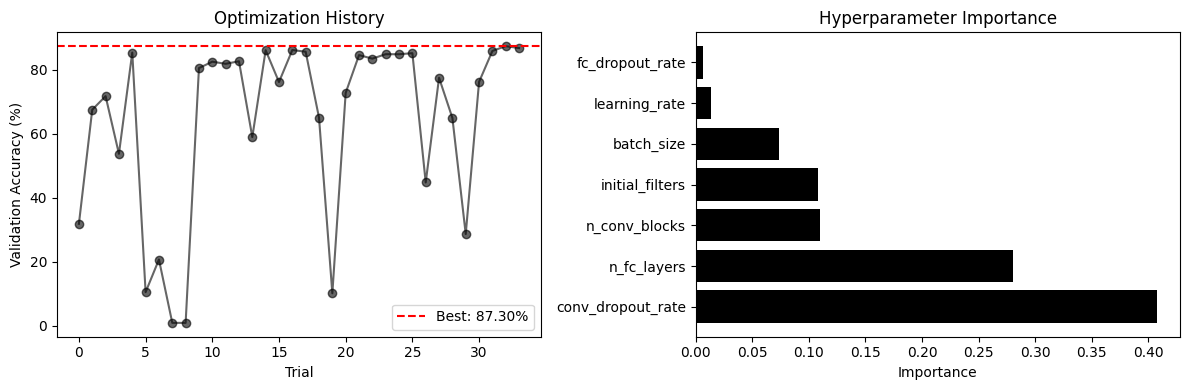

In [7]:
fig, axes = plots.plot_optimization_results(study)
plt.show()

## 3. Train final model with best hyperparameters

### 3.1. Load winning hyperparameters

In [8]:
# Extract best hyperparameters
best_params = study.best_trial.params

print('Best hyperparameters\n')
for key, value in best_params.items():
    print(f'  {key}: {value}')

Best hyperparameters

  batch_size: 64
  n_conv_blocks: 7
  initial_filters: 64
  n_fc_layers: 2
  conv_dropout_rate: 0.265682054912767
  fc_dropout_rate: 0.5786665563752931
  learning_rate: 0.0004134004326389953


### 3.2. Re-create dataloader with winning batch size

In [9]:
# Recreate data loaders with best batch size
best_batch_size = best_params['batch_size']

# Load datasets
train_dataset = data_utils.load_dataset(
    data_source=datasets.CIFAR10,
    transform=transform,
    root=config.DATA_DIR,
    train=True
)

test_dataset = data_utils.load_dataset(
    data_source=datasets.CIFAR10,
    transform=transform,
    root=config.DATA_DIR,
    train=False
)

# Prepare splits
train_dataset, val_dataset, test_dataset = data_utils.prepare_splits(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    val_size=validation_size
)

# Create dataloaders
train_loader, val_loader, test_loader = data_utils.create_dataloaders(
    train_dataset, val_dataset, test_dataset,
    batch_size=best_batch_size,
    preload_to_memory=True,
    device=config.DEVICE
)

### 3.2. Create optimized model

In [10]:
# Create model with best hyperparameters
best_model = optimization.create_cnn(
    n_conv_blocks=best_params['n_conv_blocks'],
    initial_filters=best_params['initial_filters'],
    n_fc_layers=best_params['n_fc_layers'],
    conv_dropout_rate=best_params['conv_dropout_rate'],
    fc_dropout_rate=best_params['fc_dropout_rate'],
    num_classes=len(config.CLASS_NAMES),
    in_channels=3
).to(config.DEVICE)

# Create optimizer with best learning rate (fixed Adam optimizer)
best_optimizer = optim.Adam(
    best_model.parameters(), 
    lr=best_params['learning_rate']
)

# Set cross-entropy loss
criterion = torch.nn.CrossEntropyLoss()

# Get total trainable parameters
trainable_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)

print(f'\n{best_model}')
print(f'\nTotal parameters: {trainable_params:,}')


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Dropout(p=0.265682054912767, inplace=False)
  (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): ReLU()
  (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): ReLU()
  (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (14): Dropout(p=0.265682054912767, inplace=False)
  (15): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (16): BatchNorm2d(128, eps

### 3.2. Train optimized model

In [11]:
%%time

history = training.train_model(
    model=best_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=best_optimizer,
    device=config.DEVICE,
    epochs=n_epochs_final,
    print_every=print_every,
    enable_early_stopping=True,
    early_stopping_patience=10
)

print()

Epoch   1/200 - loss: 1.8437 - acc: 27.68% - val_loss: 1.6582 - val_acc: 36.56%
Epoch  10/200 - loss: 0.7077 - acc: 77.24% - val_loss: 0.6994 - val_acc: 76.98%
Epoch  20/200 - loss: 0.4159 - acc: 86.78% - val_loss: 0.4839 - val_acc: 84.82%
Epoch  30/200 - loss: 0.2819 - acc: 91.12% - val_loss: 0.4537 - val_acc: 87.17%
Epoch  40/200 - loss: 0.1999 - acc: 93.61% - val_loss: 0.4614 - val_acc: 87.70%

Early stopping at epoch 41
Best val_loss: 0.4521 at epoch 31
Restored best model weights

CPU times: user 22min 47s, sys: 1.41 s, total: 22min 48s
Wall time: 22min 42s


### 3.3. Learning curves

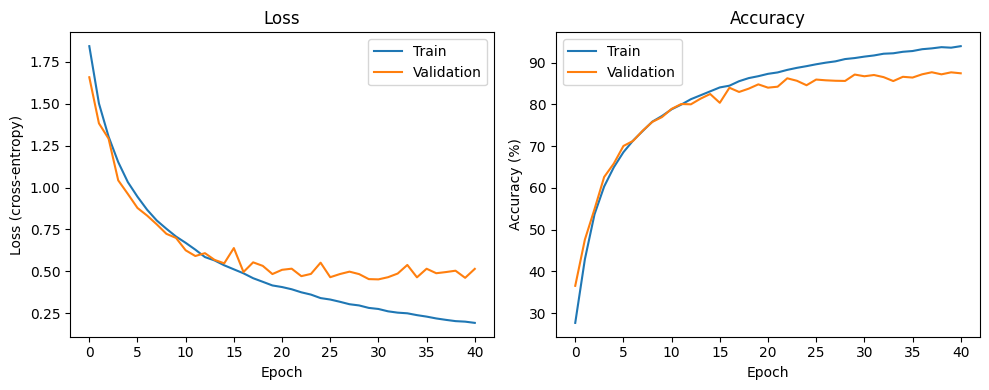

In [12]:
fig, axes = plots.plot_learning_curves(history)
plt.show()

## 4. Evaluate optimized model on test set

### 4.1. Calculate test accuracy

In [13]:
test_accuracy, predictions, true_labels = eval_utils.evaluate_model(
    best_model,
    test_loader
)

print(f'Test accuracy: {test_accuracy:.2f}%')

Test accuracy: 87.16%


### 4.2. Per-class accuracy

In [14]:
# Calculate per-class accuracy
class_correct = {name: 0 for name in config.CLASS_NAMES}
class_total = {name: 0 for name in config.CLASS_NAMES}

for pred, true in zip(predictions, true_labels):

    class_name = config.CLASS_NAMES[true]
    class_total[class_name] += 1

    if pred == true:
        class_correct[class_name] += 1

print('Per-class accuracy:')
print('-' * 30)

for name in config.CLASS_NAMES:
    acc = 100 * class_correct[name] / class_total[name]
    print(f'{name:12s}: {acc:.2f}%')

Per-class accuracy:
------------------------------
airplane    : 87.20%
automobile  : 95.30%
bird        : 82.00%
cat         : 69.70%
deer        : 91.50%
dog         : 79.00%
frog        : 92.10%
horse       : 90.20%
ship        : 94.60%
truck       : 90.00%


### 4.3. Confusion matrix

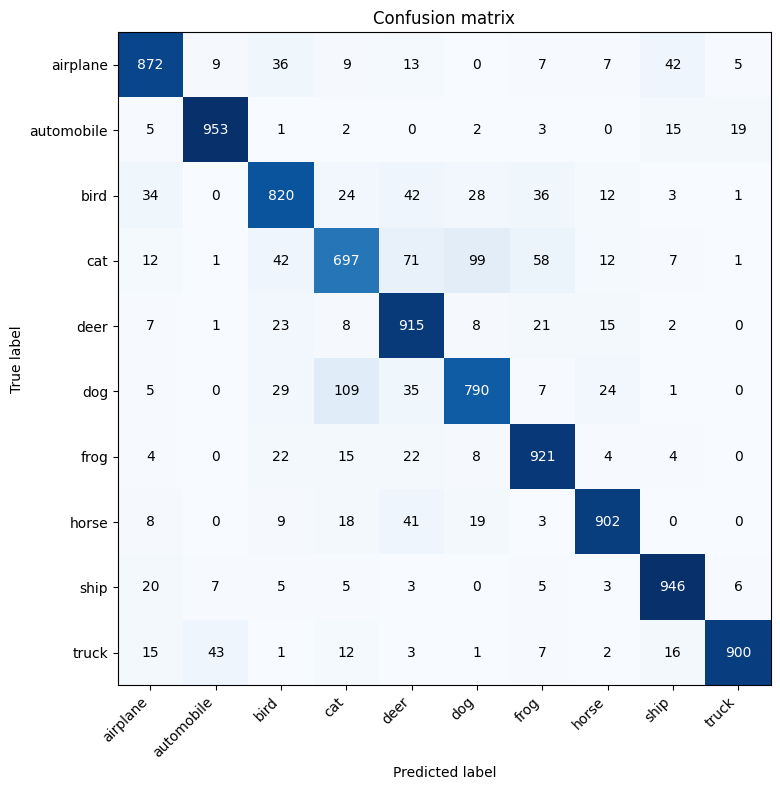

In [15]:
fig, ax = plots.plot_confusion_matrix(true_labels, predictions, config.CLASS_NAMES)
plt.show()

### 4.4. Predicted class probability distributions

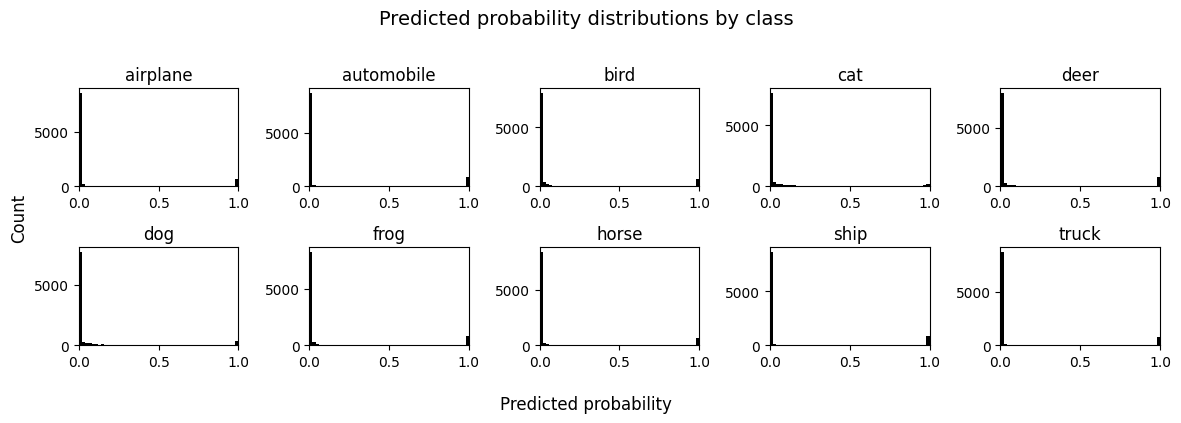

In [16]:
# Get predicted probabilities for all test samples
best_model.eval()
all_probs = []

with torch.no_grad():
    for images, _ in test_loader:
        outputs = best_model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)

# Plot probability distributions
fig, axes = plots.plot_class_probability_distributions(all_probs, config.CLASS_NAMES)
plt.show()

### 4.5. Evaluation curves

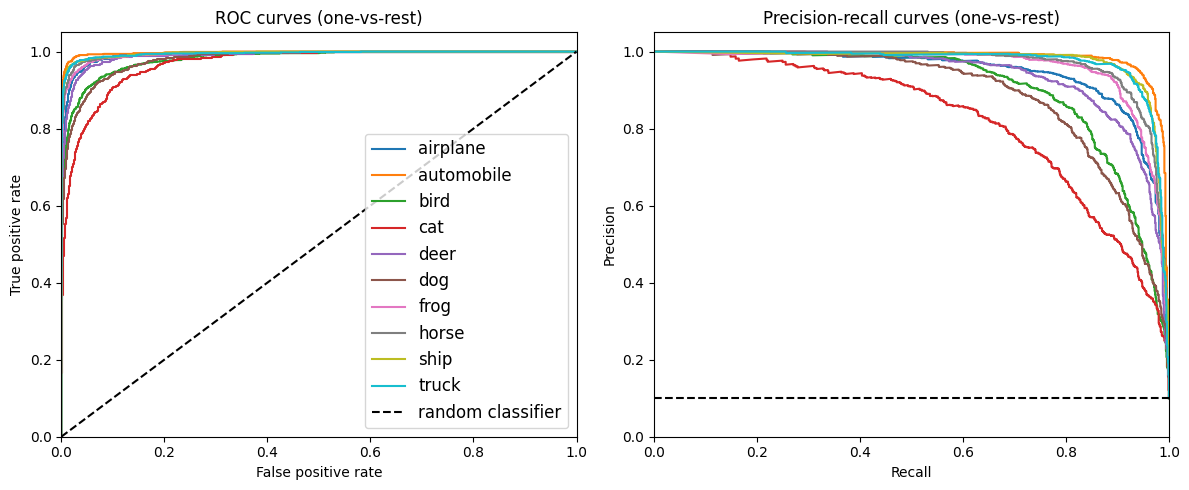

In [17]:
fig, (ax1, ax2) = plots.plot_evaluation_curves(true_labels, all_probs, config.CLASS_NAMES)
plt.show()

## 5. Save optimized model and hyperparameters

In [18]:
# Save trained model
model_path = config.MODELS_DIR / 'optimized_cnn.pth'
torch.save(best_model, model_path)

print(f'Model saved to: {model_path}')
print(f'Test accuracy: {test_accuracy:.2f}%')

Model saved to: ../models/pytorch/optimized_cnn.pth
Test accuracy: 87.16%


## 6. Save test results for comparison

In [19]:
# Save performance results
results_path = config.RESULTS_DIR / 'optimized_cnn_results.pkl'

# Count model parameters
total_params = sum(p.numel() for p in best_model.parameters())
trainable_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)

# Create results dictionary
results_dict = {
    'true_labels': true_labels,
    'predictions': predictions,
    'all_probs': all_probs,
    'test_accuracy': test_accuracy,
    'total_params': total_params,
    'trainable_params': trainable_params
}

# Save results
with open(results_path, 'wb') as f:
    pickle.dump(results_dict, f)

print(f'Test results saved to: {results_path}')
print(f'  - Test accuracy: {test_accuracy:.2f}%')
print(f'  - Total parameters: {total_params:,}')
print(f'  - Trainable parameters: {trainable_params:,}')


Test results saved to: ../data/pytorch/performance_results/optimized_cnn_results.pkl
  - Test accuracy: 87.16%
  - Total parameters: 6,405,706
  - Trainable parameters: 6,405,706
